# 1) Libraries

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 2) Load Data

In [4]:
path = r"C:\Users\ebrah\NLP\Emotions dataset"

In [5]:
train_data = pd.read_csv(os.path.join(path, 'train.txt'), encoding='latin1', sep=';', header=None, names=['text', 'emotion'])
test_data = pd.read_csv(os.path.join(path, 'test.txt'), encoding='latin1', sep=';', header=None, names=['text', 'emotion'])
train_data.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


### Shuffle train data

In [7]:
train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
train_data.head()

,text,emotion
0,ive made it through a week i just feel beaten ...,sadness
1,i feel this strategy is worthwhile,joy
2,i feel so worthless and weak what does he have...,sadness
3,i feel clever nov,joy
4,im moved in ive been feeling kind of gloomy,sadness


In [8]:
train_data.shape

(16000, 2)

In [9]:
train_data['emotion'].value_counts()

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

C:\Users\ebrah\AppData\Local\Temp\ipykernel_24016\575499626.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='emotion', data=train_data, palette='Set1')


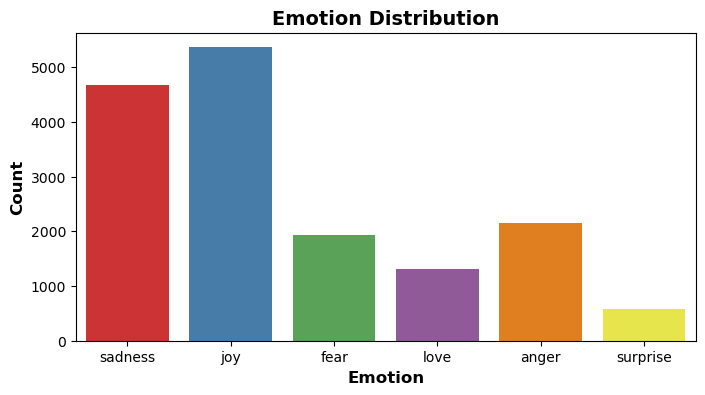

In [10]:
plt.figure(figsize=(8,4))
sns.countplot(x='emotion', data=train_data, palette='Set1')

plt.title('Emotion Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Emotion', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.show()

# 3) TF-IDF

In [12]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 4))
X_train = vectorizer.fit_transform(train_data['text'])
y_train = train_data['emotion']

X_test = vectorizer.transform(test_data['text'])
y_test = test_data['emotion']

# 4) Models

In [14]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred_LR = model.predict(X_test)
classification_report_LR = classification_report(y_test, y_pred_LR, output_dict=True)

In [15]:
model1 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
model1.fit(X_train, y_train)

y_pred_RFC = model1.predict(X_test)
classification_report_RFC = classification_report(y_test, y_pred_RFC, output_dict=True)

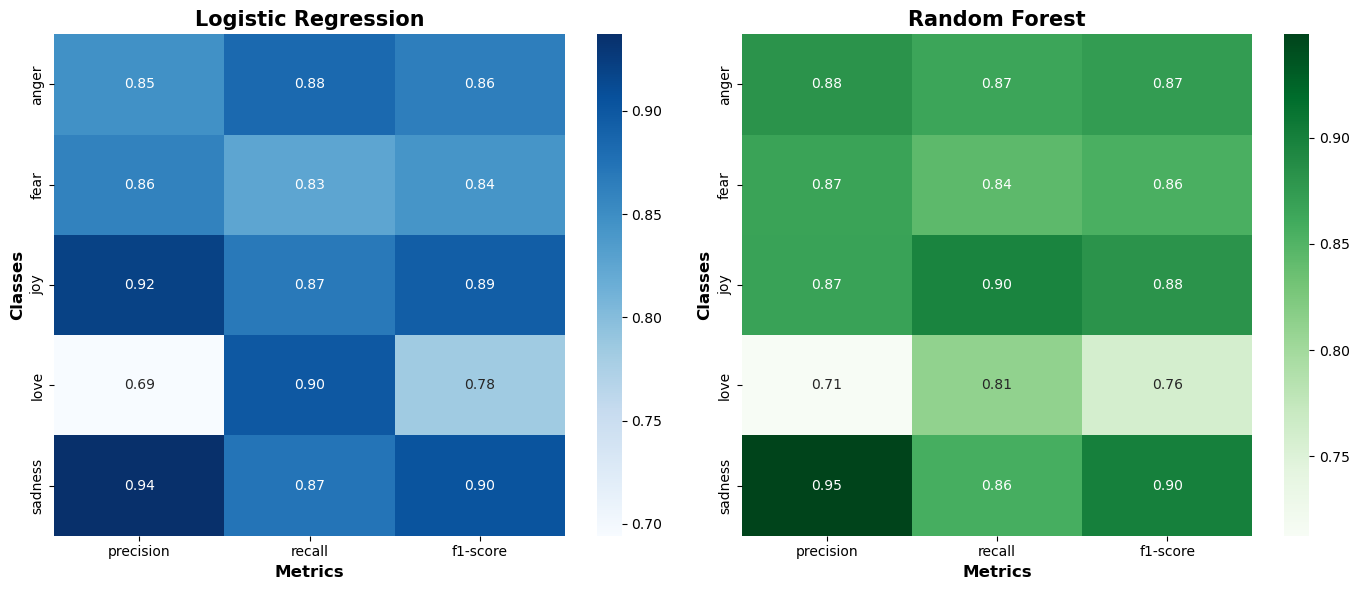

In [16]:
df1 = pd.DataFrame(classification_report_LR).transpose()
df1 = df1.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

df2 = pd.DataFrame(classification_report_RFC).transpose()
df2 = df2.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(df1.iloc[:-1, :-1], annot=True, cmap='Blues', fmt=".2f", ax=axes[0])
axes[0].set_title("Logistic Regression", fontsize=15, fontweight='bold')
axes[0].set_ylabel("Classes", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Metrics", fontsize=12, fontweight='bold')

sns.heatmap(df2.iloc[:-1, :-1], annot=True, cmap='Greens', fmt=".2f", ax=axes[1])
axes[1].set_title("Random Forest", fontsize=15, fontweight='bold')
axes[1].set_ylabel("Classes", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Metrics", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
import joblib

# Save your trained model and vectorizer
joblib.dump(model, "emotion_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("✅ Model and vectorizer saved successfully!")


✅ Model and vectorizer saved successfully!
